In [8]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe
from behave_analysis.process.session import get_experiment


In [9]:
# JAL1 SEQ3
JAL1_SEQ3_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\full_video_dataframe.csv"
seq3_video_df = pl.read_csv(JAL1_SEQ3_video_df)

# JAL1 SEQ2
JAL1_SEQ2_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\full_video_dataframe.csv" 
seq2_video_df = pl.read_csv(JAL1_SEQ2_video_df)

# JAL2 SEQ2
JAL2_SEQ2_video_df =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\full_video_dataframe.csv"
jal2_seq2_df = pl.read_csv(JAL2_SEQ2_video_df)

# JAl2 SEQ3
JAL2_SEQ3_video_df =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\full_video_dataframe.csv"
jal2_seq3_df = pl.read_csv(JAL2_SEQ3_video_df)


In [10]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

In [11]:
experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

In [12]:
for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)

In [13]:
print(loaded_session)

NEW_Session(name='Mouse: JAL004, Experiment: flip, Run number: 0', number=0, mouse='JAL004', date='2023_09_11', experiment='flip', shelter_time=[0.33, -1], barrier_time=[67.08, -1], barrier_flip_time=233.25, file_path='JAL004\\004_flip_puff2_2023_09_11T09_32_25', base_path='Z:\\Jasmine_Laurence\\Experimental_Data', processed_path='JAL004\\004_flip_puff2_2023_09_11T09_32_25\\processed_data', metadata_file='JAL004\\004_flip_puff2_2023_09_11T09_32_25\\processed_data\\metadata', shelter_location=None, barrier_location=None, daq_sampling_rate=15000, camera_trigger=None, audio=None, video=None, ttl=None, ephys=None, homing=None, threshold_crossing=None)


In [14]:
def shelter_occupancy(video_df):
    """Make a bar plot of minutes in and out of shelter per condition in each session"""
    _, ax = plt.subplots(figsize=(10, 5))
    conditions = ["shelter_only", "barrier_present"]
    fps = 40
    for x, c in enumerate(conditions):
        time_out_of_shelter = len(filter_video_dataframe(video_df, c, outofshelter=True, exclude_escape=False)) / fps
        plt.bar(
            x + 0.9,
            time_out_of_shelter / 60,
            width=0.2,
            color="dimgrey",
        )
        time_in_shelter = len(filter_video_dataframe(video_df, c, outofshelter=False, exclude_escape=False)) / fps
        plt.bar(
            x + 1.1,
            time_in_shelter / 60,
            width=0.2,
            color="lightgrey",
        )
    plt.xticks(np.arange(len(conditions)) + 1, conditions, rotation=35)
    plt.ylabel("Time (mins)")
    plt.legend(["out of shelter", "in shelter"], facecolor="white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    plt.tight_layout()

In [15]:
jal2_seq2_df
print(type(jal2_seq2_df))

<class 'polars.dataframe.frame.DataFrame'>


Example with a single session

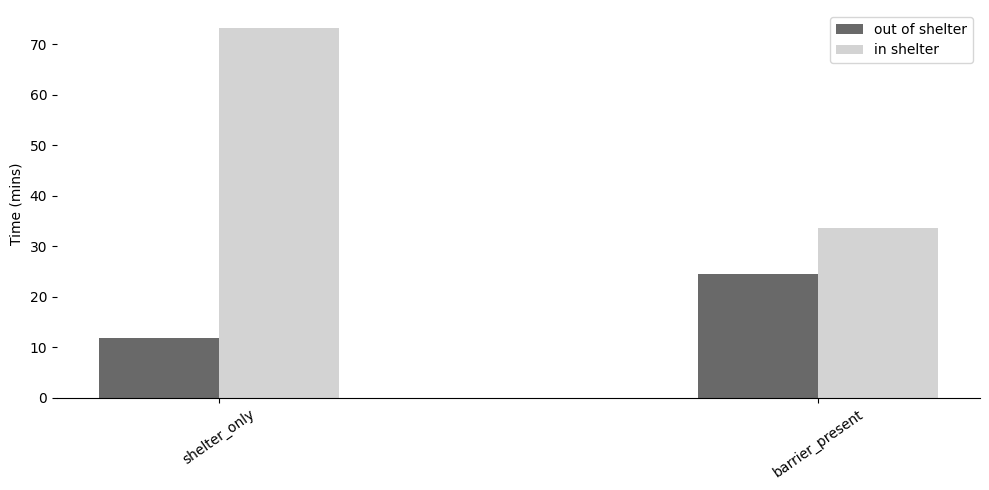

In [16]:
# Ensure the plot is inline
%matplotlib inline
shelter_occupancy(jal2_seq2_df)

Add multiple sessions to be more rigours

In [17]:
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"

In [18]:
def shelter_occupancy(video_dfs):
    """
    Plot and statistically compare time spent in and out of shelter across multiple sessions and conditions.

    For each session and each condition ("shelter_only", "barrier_present"), this function:
    - Computes the total time spent out of shelter and in shelter (in minutes).
    - Plots the mean and SEM for each group as a bar plot.
    - Performs a paired t-test comparing out-of-shelter and in-shelter times within each condition.
    - Annotates the plot with significance stars and p-values.
    - Saves the figure as an EPS file for publication.

    Parameters
    ----------
    video_dfs : list of polars.DataFrame
        List of session DataFrames, each containing behavioral data for one session.

    Returns
    -------
    None
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.stats import ttest_rel
    import os

    # Set publication-ready plotting parameters
    plt.rcParams.update({
        "font.size": 18,
        "font.family": "Arial",
        "axes.labelsize": 20,
        "axes.titlesize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
    })

    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    conditions = ["shelter_only", "barrier_present"]
    fps = 40  # Frames per second of video

    # Initialize array to hold times: shape (n_sessions, n_conditions, 2 [out, in])
    times = np.zeros((len(video_dfs), len(conditions), 2))
    for i, video_df in enumerate(video_dfs):
        for j, c in enumerate(conditions):
            # Compute time out of shelter (in minutes)
            out_time = len(filter_video_dataframe(video_df, c, outofshelter=True, exclude_escape=False)) / fps / 60
            # Compute time in shelter (in minutes)
            in_time = len(filter_video_dataframe(video_df, c, outofshelter=False, exclude_escape=False)) / fps / 60
            times[i, j, 0] = out_time
            times[i, j, 1] = in_time

    # Calculate mean and SEM across sessions for each bar
    means = times.mean(axis=0)  # shape (n_conditions, 2)
    sems = times.std(axis=0, ddof=1) / np.sqrt(times.shape[0])

    fig, ax = plt.subplots(figsize=(7, 5))
    bar_width = 0.28
    x = np.arange(len(conditions))

    # Plot bars for out-of-shelter and in-shelter times
    bars_out = ax.bar(
        x - bar_width/2, means[:, 0], yerr=sems[:, 0], width=bar_width,
        color="dimgrey", label="Out of shelter", capsize=7, edgecolor='black', linewidth=1.2
    )
    bars_in = ax.bar(
        x + bar_width/2, means[:, 1], yerr=sems[:, 1], width=bar_width,
        color="lightgrey", label="In shelter", capsize=7, edgecolor='black', linewidth=1.2
    )

    # Paired t-test for each condition: out vs in
    for j, c in enumerate(conditions):
        # If only one session, skip stats
        if times.shape[0] < 2:
            pval = np.nan
            stars = 'n/a'
        else:
            tstat, pval = ttest_rel(times[:, j, 0], times[:, j, 1])
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            else:
                stars = 'n.s.'
        # Annotate plot
        y_max = max(means[j, 0] + sems[j, 0], means[j, 1] + sems[j, 1])
        y = y_max + 0.1 * y_max
        ax.plot([x[j] - bar_width/2, x[j] + bar_width/2], [y, y], color='black', linewidth=1.5)
        ax.text(x[j], y + 0.03 * y_max, f"{stars}\np={pval:.3g}", ha='center', va='bottom', fontsize=16, fontweight='bold')

    # Final plot formatting
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, rotation=0, ha='right')
    ax.set_ylabel("Time (mins)")
    ax.set_xlabel("Condition")
    ax.legend(facecolor="white", frameon=False, loc='upper left')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(width=1.2, length=6)
    plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)
    plt.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
    plt.show()

    # Save figure as EPS for publication
    fig.savefig(os.path.join(save_path, "shelter_occupancy_bar_plot.eps"), format='eps', bbox_inches='tight', dpi=300)

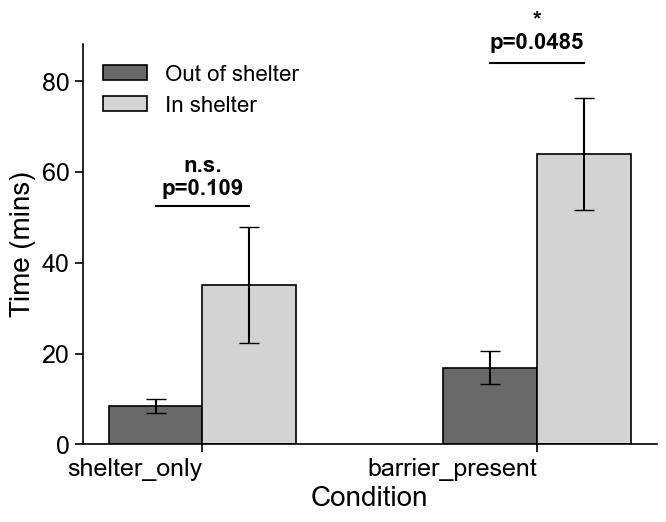

In [19]:
shelter_occupancy([seq2_video_df, seq3_video_df, jal2_seq3_df, jal2_seq2_df])

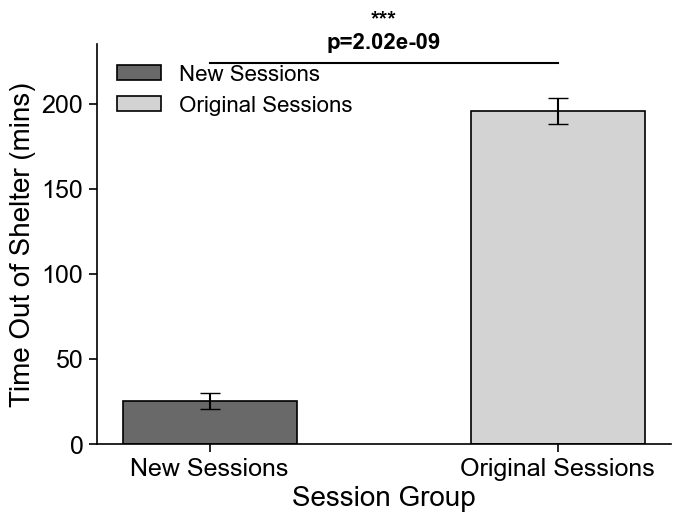

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe
from behave_analysis.process.session import get_experiment

def compare_shelter_occupancy(new_sessions, experiment_objects):
    """
    Compare time spent out of shelter across all conditions for new sessions vs original experiment sessions.

    Parameters
    ----------
    new_sessions : list of polars.DataFrame
        List of DataFrames for the new sessions.
    experiment_objects : list
        List of experiment objects to load and process.

    Returns
    -------
    None
    """
    # Set publication-ready plotting parameters
    plt.rcParams.update({
        "font.size": 18,
        "font.family": "Arial",
        "axes.labelsize": 20,
        "axes.titlesize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
    })

    fps = 40  # Frames per second of video

    # Calculate time out of shelter for new sessions
    new_out_times = []
    for video_df in new_sessions:
        # Automatically consider all conditions
        out_time = len(filter_video_dataframe(video_df, condition=None, outofshelter=True, exclude_escape=False)) / fps / 60
        new_out_times.append(out_time)

    # Calculate time out of shelter for original experiment sessions
    original_out_times = []
    for session in experiment_objects:
        loaded_session = get_experiment(session)
        video_df_path = os.path.join(
            loaded_session.base_path,
            loaded_session.processed_path,
            "full_video_dataframe.csv"
        )
        if os.path.exists(video_df_path):
            video_df = pl.read_csv(video_df_path)
            out_time = len(filter_video_dataframe(video_df, condition=None, outofshelter=True, exclude_escape=False)) / fps / 60
            original_out_times.append(out_time)

    # Calculate mean and SEM for both groups
    new_mean = np.mean(new_out_times)
    new_sem = np.std(new_out_times, ddof=1) / np.sqrt(len(new_out_times))
    original_mean = np.mean(original_out_times)
    original_sem = np.std(original_out_times, ddof=1) / np.sqrt(len(original_out_times))

    # Create the bar plot
    fig, ax = plt.subplots(figsize=(7, 5))
    bar_width = 0.5
    x = np.arange(2)  # Two bars: new sessions and original sessions

    # Plot bars
    ax.bar(
        x[0], new_mean, yerr=new_sem, width=bar_width,
        color="dimgrey", label="New Sessions", capsize=7, edgecolor='black', linewidth=1.2
    )
    ax.bar(
        x[1], original_mean, yerr=original_sem, width=bar_width,
        color="lightgrey", label="Original Sessions", capsize=7, edgecolor='black', linewidth=1.2
    )

    # Annotate plot with significance stars (optional)
    from scipy.stats import ttest_ind
    tstat, pval = ttest_ind(new_out_times, original_out_times)
    if pval < 0.001:
        stars = '***'
    elif pval < 0.01:
        stars = '**'
    elif pval < 0.05:
        stars = '*'
    else:
        stars = 'n.s.'
    y_max = max(new_mean + new_sem, original_mean + original_sem)
    y = y_max + 0.1 * y_max
    ax.plot([x[0], x[1]], [y, y], color='black', linewidth=1.5)
    ax.text(np.mean(x), y + 0.03 * y_max, f"{stars}\np={pval:.3g}", ha='center', va='bottom', fontsize=16, fontweight='bold')

    # Final plot formatting
    ax.set_xticks(x)
    ax.set_xticklabels(["New Sessions", "Original Sessions"], rotation=0, ha='center')
    ax.set_ylabel("Time Out of Shelter (mins)")
    ax.set_xlabel("Session Group")
    ax.legend(facecolor="white", frameon=False, loc='upper left')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(width=1.2, length=6)
    plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)
    plt.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
    plt.show()

    # Save figure as EPS for publication
    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    fig.savefig(os.path.join(save_path, "shelter_occupancy_comparison.eps"), format='eps', bbox_inches='tight', dpi=300)

# Example usage
new_sessions = [seq2_video_df, seq3_video_df, jal2_seq3_df, jal2_seq2_df]
compare_shelter_occupancy(new_sessions, experiments_objects)